## Libraries

In [1]:
import os

In [2]:
run = 'local' #local or cloud
os.environ["APP_ENV"] = run

In [3]:
import sys
sys.path.append('..')

In [5]:
from src.grass_functions import*
from src.process_inputs import*
%matplotlib inline
#%load_ext autoreload
#%autoreload 2

# Parameters

In [6]:
#set project variables
Project_Area = 'haw_river_no_survey'
projection = '2264' #set to None if you want to use the DEM's original projection
res = '1m'

## Set variables analysis
source = 'user-defined' #wbd or user-defined
data_scale = 'name' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
select_data = 'site' #     # Value within the filter_field used for data selection
to_headwaters = False #False if only interested in local huc area
input_shp_name = 'haw_aoi.shp' #None or must be populated populated with a shapefile polygons if data_scale != HUCXX
buffer = 2000
auto_delete = False

#Additional variables
in_tifs = ['Alamance_QL1_2024_03ft_CountywideRaster.tif'] #in priority order
dem = 'dem_'+str(select_data)
aligned = False
align_rast = dem[0] #set to False if no realignment needed

In [7]:
if data_scale.find('HUC') >= 0:
    huc_level = re.findall("[0-9]+",data_scale)[0]
    if huc_level == str(len(select_data)):
        huc_digys = huc_level
    else:
        huc_digys = huc_level
        select_data = select_data[:int(huc_digys)]

In [8]:
## Paths:
parent_dir = pl.Path(os.getcwd()).parent/'data'
current_dir = pl.Path(os.getcwd())
outputs_dir =parent_dir/'Rasters'/Project_Area/'Outputs'
vector_dir = parent_dir/'Vectors'/Project_Area
raster_dir = parent_dir/'Rasters'/Project_Area
huc_path = vector_dir/'{}_aoi.geojson'.format(Project_Area)
git_data_repo = current_dir/'data_repository'
if input_shp_name:
    input_shp = vector_dir/input_shp_name
directory = outputs_dir

### Get area of interest

In [9]:
#prep work
if data_scale.find('HUC') >= 0:
    wbd = nhd_download(select_data,vector_dir)

    #read in HUC12s vector file from NHD
    local_huc4 = gpd.read_file(vector_dir/wbd, layer='WBDHU{}'.format(huc_digys))

    #reformat fields to handle disparate USGS data formats
    local_huc4 = lower_pd_cols(local_huc4.copy())
    if to_headwaters:
        ## function to get most downstream HUC12 if HUC10 or HUC8 is entered
        select_data = get_downstream_huc12(select_data,local_huc4)

        #get all upstream HUC12s
        local_huc12 = local_huc4.loc[local_huc4['huc12'] == select_data]
        upstream_list = get_upstream_extent_usgs(select_data) #selected huc12
        aoi = local_huc4.loc[local_huc4['huc12'].isin(upstream_list) == True]
    else:
        aoi = local_huc4.loc[local_huc4['huc{}'.format(huc_digys)] == select_data]
        local_huc12 = None
else:
    aoi = gpd.read_file(input_shp)
    local_huc12 = None
#save to vector for later analysis
huc_path = vector_dir/'{0}_{1}_aoi.geojson'.format(Project_Area,select_data)
#fix topological errors
aoi['geometry'] = aoi.buffer(0) 
aoi.to_crs(epsg=projection).to_file(str(huc_path),driver="GeoJSON")

[2026-05-12 09:47:05,904] [INFO] [raw] : Created 1 records


In [10]:
aoi = gpd.read_file(str(huc_path),driver="GeoJSON")


c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


### Start new grass session

In [11]:
# define GRASS data settings (adapt to your needs)
location = Project_Area+'_'+projection
mapset = 'PERMANENT'

In [12]:
initialize_grass_db(location, mapset, projection)

{'GISDBASE': "'C:\\Users\\Curtis.Smith\\Documents\\grassdata';", 'LOCATION_NAME': "'haw_river_no_survey_2264';", 'MAPSET': "'PERMANENT';"}
Database Mapset Exists
None
{'GISDBASE': 'C:\\Users\\Curtis.Smith\\Documents\\grassdata', 'LOCATION_NAME': 'haw_river_no_survey_2264', 'MAPSET': 'PERMANENT'}


#### Review existing files

In [13]:
gs.run_command('g.remove',type='raster',name='None',flags='f')

0

In [27]:
#list all grass files
grass_maps = list_existing_grass(print_it=True)

Available vector maps:
aoi@PERMANENT
aoi_buffer@PERMANENT

Available raster maps:
Alamance_QL1_2024_03ft_CountywideRaster@PERMANENT
MASK@PERMANENT


### Get Raster data

In [15]:
for in_tif in in_tifs:
    gs.run_command('r.in.gdal', input=raster_dir/'dem'/in_tif, output= in_tif.removesuffix('.tif'))

## Align to specific grid (optional)

In [16]:
#add project area
basins = 'aoi'
gs.run_command('v.import', input= huc_path,  output= basins)

0

In [17]:
##buffer
gs.run_command('v.buffer',input=basins,output=f'{basins}_buffer',distance = buffer)

0

In [19]:
gs.run_command('g.region',vector = f'{basins}_buffer',align=in_tifs[0].removesuffix('.tif'))

0

In [20]:
gs.parse_command('g.region',flags='pg')

{'projection': '99',
 'zone': '0',
 'n': '846850',
 's': '840368.75',
 'w': '1892650',
 'e': '1899315.625',
 'nsres': '3.125',
 'ewres': '3.125',
 'rows': '2074',
 'cols': '2133',
 'cells': '4423842'}

In [21]:
gs.run_command('r.mask',vector = f'{basins}_buffer')

0

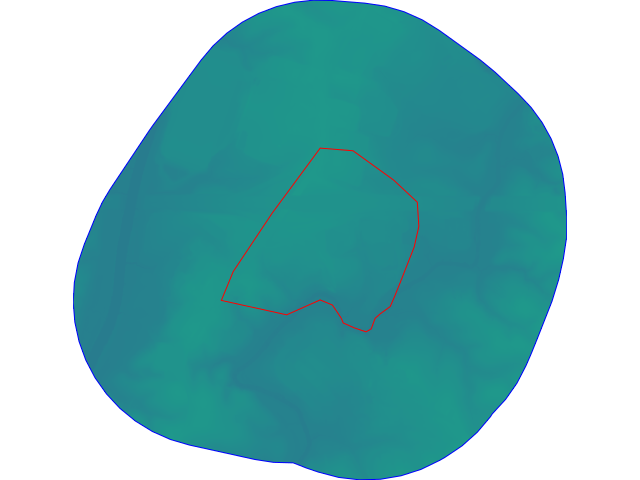

In [22]:
gs.run_command('d.erase')
for in_tif in in_tifs:
    gs.run_command('d.rast', map= in_tif.removesuffix('.tif'))
gs.run_command('d.vect', map= basins,color='red',fill_color='None')
gs.run_command('d.vect', map=f'{basins}_buffer',color='blue',fill_color='None')
Image(filename="map.png")

In [28]:
#patch but smoothly   
assert len(in_tifs) <=2, "curtis needs to adapt code to handle more than 2 tifs"
if len(in_tifs) == 2:
    gs.run_command('r.patch.smooth', input_a=in_tifs[0].removesuffix('.tif'),input_b = in_tifs[1].removesuffix('.tif'), output=dem,overlap='review_file', transition_angle=2,flags='s')

else:
    gs.run_command('g.rename', raster=(in_tifs[0].removesuffix('.tif'),dem))

# confirm cell sizes

In [30]:
gs.parse_command('r.info',map=dem, flags='g')

{'north': '915000',
 'south': '757500',
 'east': '1935000',
 'west': '1835000',
 'nsres': '3.125',
 'ewres': '3.125',
 'rows': '50400',
 'cols': '32000',
 'cells': '1612800000',
 'datatype': 'FCELL',
 'ncats': '0'}

In [31]:
gs.run_command('r.out.gdal', input= dem, output= raster_dir/f'{Project_Area}_dem_.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')

0

In [32]:
if len(in_tifs) >1:
    gs.run_command('r.out.gdal', input= 'review_file', output= raster_dir/f'{Project_Area}_dem_review.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')

## END